In [1]:
from pathlib import Path

import pandas as pd
from tqdm import tqdm

In [2]:
DATA_DIR = Path("output")
CSV_PATTERN = "dataset_winsize*_when.csv"

OUTPUT_DIR = Path("model_outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

RANDOM_STATE = 42
DEVICE = "cuda:0"

DROP_COLUMNS = [
    "fold_id",
    "label_is_auto",
    "label_time_to_event_seconds",
    "label_from_zone",
    "label_to_zone",
]

REGRESSION_SUMMARY_FILENAME = "regression_summary_XGBoost.csv"

In [3]:
csv_files = sorted(
    DATA_DIR.glob(CSV_PATTERN),
    key=lambda p: float(p.stem.split("winsize", 1)[1].removesuffix("h_when")),
)
csv_file_path = csv_files[4]

csv_file_path, csv_files

(PosixPath('output/dataset_winsize3h_when.csv'),
 [PosixPath('output/dataset_winsize0.25h_when.csv'),
  PosixPath('output/dataset_winsize0.5h_when.csv'),
  PosixPath('output/dataset_winsize1h_when.csv'),
  PosixPath('output/dataset_winsize2h_when.csv'),
  PosixPath('output/dataset_winsize3h_when.csv'),
  PosixPath('output/dataset_winsize4h_when.csv'),
  PosixPath('output/dataset_winsize5h_when.csv'),
  PosixPath('output/dataset_winsize6h_when.csv'),
  PosixPath('output/dataset_winsize7h_when.csv'),
  PosixPath('output/dataset_winsize8h_when.csv'),
  PosixPath('output/dataset_winsize9h_when.csv'),
  PosixPath('output/dataset_winsize10h_when.csv'),
  PosixPath('output/dataset_winsize11h_when.csv'),
  PosixPath('output/dataset_winsize12h_when.csv')])

In [4]:
df = pd.read_csv(csv_file_path)

print(f"\nReading {csv_file_path}")


Reading output/dataset_winsize3h_when.csv


# Stage1: Obtain optimal window size

In [5]:
import numpy as np
from xgboost import XGBRegressor

TRAIN_FOLDS = [0, 1, 2, 3, 4]
TEST_FOLD = -1
regression_target = "label_time_to_event_seconds"


def _as_numpy(values):
    if hasattr(values, "get") and not isinstance(values, (pd.Series, pd.DataFrame)):
        values = values.get()
    return np.asarray(values, dtype=float)


def mae_loss(y_true, y_pred):
    return float(np.mean(np.abs(_as_numpy(y_true) - _as_numpy(y_pred))))


xgboost_window_models = []
xgboost_window_test_losses = []

for dataset_path in tqdm(csv_files):
    dataset_df = pd.read_csv(dataset_path)
    train_df = dataset_df[dataset_df["fold_id"].isin(TRAIN_FOLDS)].copy()
    test_df = dataset_df[dataset_df["fold_id"] == TEST_FOLD].copy()

    X_train = train_df.drop(columns=DROP_COLUMNS, errors="ignore")
    X_train = X_train.select_dtypes(include=["number", "bool"])
    y_train = train_df[regression_target].astype(float)
    train_mask = y_train.notna()
    X_train = X_train.loc[train_mask]
    y_train = y_train.loc[train_mask]

    X_test = test_df.drop(columns=DROP_COLUMNS, errors="ignore")
    X_test = X_test.select_dtypes(include=["number", "bool"])
    y_test = test_df[regression_target].astype(float)
    test_mask = y_test.notna()
    X_test = X_test.loc[test_mask]
    y_test = y_test.loc[test_mask]

    model = XGBRegressor(
        objective="reg:quantileerror",
        quantile_alpha=0.5,
        eval_metric="mae",
        tree_method="hist",
        device=DEVICE,
        n_jobs=1,
        random_state=RANDOM_STATE,
        n_estimators=100,
        learning_rate=0.1,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_lambda=1.0,
    )
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    test_loss = mae_loss(y_test, y_pred)

    xgboost_window_models.append(model)
    xgboost_window_test_losses.append(test_loss)

    print(f"{dataset_path.name}: test MAE={test_loss:.6f}")

xgboost_window_test_losses

  0%|          | 0/14 [00:00<?, ?it/s]/home/aj/venv/lib/python3.11/site-packages/xgboost/core.py:751: UserWarning: [01:43:27] WARNING: /__w/xgboost/xgboost/src/common/error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)
  7%|▋         | 1/14 [00:00<00:07,  1.81it/s]

dataset_winsize0.25h_when.csv: test MAE=4997.413927


 14%|█▍        | 2/14 [00:00<00:04,  2.67it/s]

dataset_winsize0.5h_when.csv: test MAE=4971.095128


 21%|██▏       | 3/14 [00:01<00:03,  3.32it/s]

...

 93%|█████████▎| 13/14 [00:03<00:00,  4.29it/s]

dataset_winsize11h_when.csv: test MAE=5000.004580


100%|██████████| 14/14 [00:03<00:00,  3.95it/s]

dataset_winsize12h_when.csv: test MAE=4995.292164


[4997.413926662359,
 4971.09512816057,
 4974.226364760371,
 4901.372948566077,
 4884.053275380019,
 4884.257081505848,
 4831.713428978534,
 4914.11960014783,
 4917.176093411425,
 4937.786740104656,
 4980.337444257617,
 4950.408757693387,
 5000.0045801352335,
 4995.292164330096]

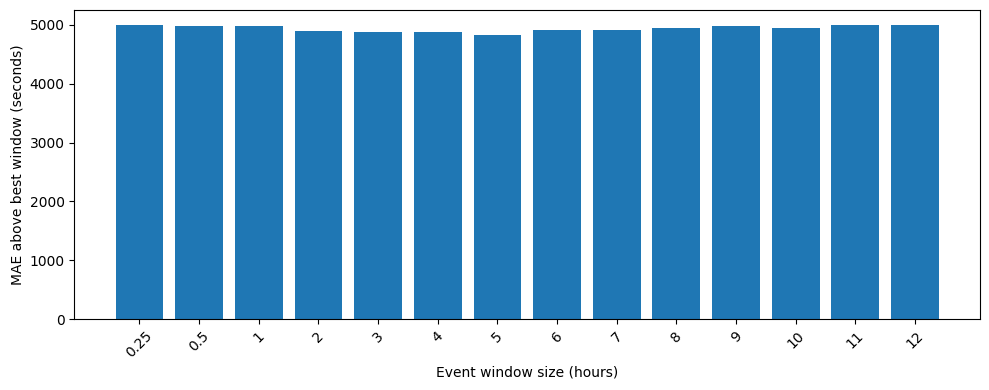

In [6]:
import matplotlib.pyplot as plt

window_sizes = [
    path.stem.split("winsize", 1)[1].removesuffix("h_when") for path in csv_files
]

plt.figure(figsize=(10, 4))
plt.bar(window_sizes, xgboost_window_test_losses)
plt.xlabel("Event window size (hours)")
plt.ylabel("MAE above best window (seconds)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

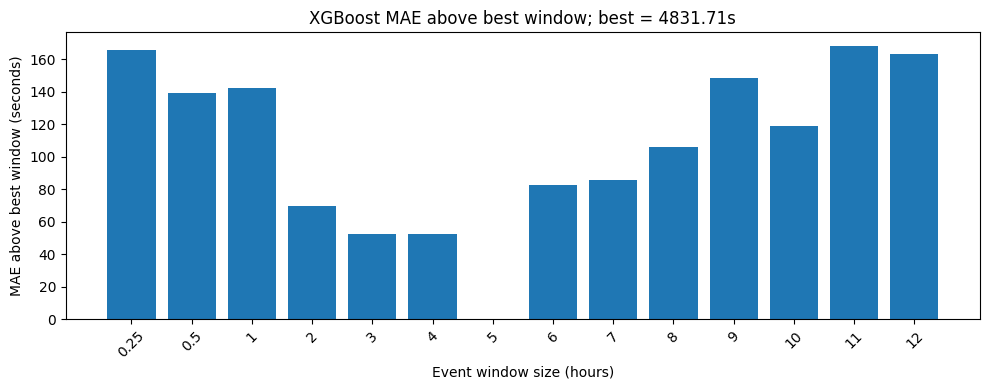

In [7]:
best_loss = min(xgboost_window_test_losses)
loss_above_best = [loss - best_loss for loss in xgboost_window_test_losses]

plt.figure(figsize=(10, 4))
plt.bar(window_sizes, loss_above_best)
plt.xlabel("Event window size (hours)")
plt.ylabel("MAE above best window (seconds)")
plt.title(f"XGBoost MAE above best window; best = {best_loss:.2f}s")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# stage 2: Search parameters

In [8]:
import json

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV, PredefinedSplit
from xgboost import XGBRegressor

# Optimal window from stage 1.
OPTIMAL_WINDOW_HOURS = 5
optimal_dataset_path = DATA_DIR / f"dataset_winsize{OPTIMAL_WINDOW_HOURS:g}h_when.csv"

GRID_SEARCH_OUTPUT_DIR = (
    OUTPUT_DIR / f"xgboost_gridcv_winsize{OPTIMAL_WINDOW_HOURS:g}h_when"
)

REFIT_METRIC = "neg_mean_absolute_error"
GRID_N_JOBS = 1
GRID_VERBOSE = 2

XGB_N_ESTIMATORS_VALUES = [100, 300]
XGB_LEARNING_RATE_VALUES = [0.03, 0.1]
XGB_MAX_DEPTH_VALUES = [3, 5]
XGB_MIN_CHILD_WEIGHT_VALUES = [1, 5]
XGB_SUBSAMPLE_VALUES = [0.8, 1.0]

xgb_param_grid = {
    "n_estimators": XGB_N_ESTIMATORS_VALUES,
    "learning_rate": XGB_LEARNING_RATE_VALUES,
    "max_depth": XGB_MAX_DEPTH_VALUES,
    "min_child_weight": XGB_MIN_CHILD_WEIGHT_VALUES,
    "subsample": XGB_SUBSAMPLE_VALUES,
}

dataset_df = pd.read_csv(optimal_dataset_path)
trainval_df = dataset_df[dataset_df["fold_id"].isin(TRAIN_FOLDS)].copy()
test_df = dataset_df[dataset_df["fold_id"] == TEST_FOLD].copy()

X_trainval = trainval_df.drop(columns=DROP_COLUMNS, errors="ignore").select_dtypes(
    include=["number", "bool"]
)
y_trainval = trainval_df[regression_target].astype(float)
trainval_mask = y_trainval.notna()
X_trainval = X_trainval.loc[trainval_mask]
y_trainval = y_trainval.loc[trainval_mask]
cv = PredefinedSplit(trainval_df.loc[trainval_mask, "fold_id"].to_numpy())

X_test = test_df.drop(columns=DROP_COLUMNS, errors="ignore").select_dtypes(
    include=["number", "bool"]
)
y_test = test_df[regression_target].astype(float)
test_mask = y_test.notna()
X_test = X_test.loc[test_mask]
y_test = y_test.loc[test_mask]

xgb_grid_search = GridSearchCV(
    estimator=XGBRegressor(
        objective="reg:quantileerror",
        quantile_alpha=0.5,
        eval_metric="mae",
        tree_method="hist",
        device=DEVICE,
        n_jobs=1,
        random_state=RANDOM_STATE,
    ),
    param_grid=xgb_param_grid,
    scoring={
        "neg_mean_absolute_error": "neg_mean_absolute_error",
        "neg_root_mean_squared_error": "neg_root_mean_squared_error",
        "r2": "r2",
    },
    refit=REFIT_METRIC,
    cv=cv,
    n_jobs=GRID_N_JOBS,
    verbose=GRID_VERBOSE,
    return_train_score=True,
)

xgb_grid_search.fit(X_trainval, y_trainval)

xgb_cv_results = pd.DataFrame(xgb_grid_search.cv_results_)
xgb_cv_results.to_csv(GRID_SEARCH_OUTPUT_DIR / "xgboost_cv_results.csv", index=False)

xgb_y_pred = xgb_grid_search.predict(X_test)
xgb_test_mae = mean_absolute_error(y_test, xgb_y_pred)
xgb_test_rmse = mean_squared_error(y_test, xgb_y_pred) ** 0.5
xgb_test_r2 = r2_score(y_test, xgb_y_pred)

xgb_best_params = {
    "refit_metric": REFIT_METRIC,
    "best_cv_mae": float(-xgb_grid_search.best_score_),
    "test_mae": float(xgb_test_mae),
    "test_rmse": float(xgb_test_rmse),
    "test_r2": float(xgb_test_r2),
    "best_params": xgb_grid_search.best_params_,
}
(GRID_SEARCH_OUTPUT_DIR / "xgboost_best_params.json").write_text(
    json.dumps(xgb_best_params, indent=4)
)

xgb_test_predictions = pd.DataFrame(
    {
        "y_true": y_test.to_numpy(),
        "y_pred": xgb_y_pred,
        "absolute_error": np.abs(y_test.to_numpy() - xgb_y_pred),
    }
)
xgb_test_predictions.to_csv(
    GRID_SEARCH_OUTPUT_DIR / "xgboost_test_predictions.csv",
    index=False,
)

xgb_gridcv_summary = pd.DataFrame([xgb_best_params])
xgb_gridcv_summary.to_csv(
    GRID_SEARCH_OUTPUT_DIR / "xgboost_gridcv_summary.csv",
    index=False,
)

print(f"Best CV MAE: {-xgb_grid_search.best_score_:.6f}")
print(f"Test MAE: {xgb_test_mae:.6f}")
print(f"Best params: {xgb_grid_search.best_params_}")

xgb_gridcv_summary

Fitting 5 folds for each of 32 candidates, totalling 160 fits
[CV] END learning_rate=0.03, max_depth=3, min_child_weight=1, n_estimators=100, subsample=0.8; total time=   0.2s
[CV] END learning_rate=0.03, max_depth=3, min_child_weight=1, n_estimators=100, subsample=0.8; total time=   0.2s
[CV] END learning_rate=0.03, max_depth=3, min_child_weight=1, n_estimators=100, subsample=0.8; total time=   0.2s
[CV] END learning_rate=0.03, max_depth=3, min_child_weight=1, n_estimators=100, subsample=0.8; total time=   0.2s
[CV] END learning_rate=0.03, max_depth=3, min_child_weight=1, n_estimators=100, subsample=0.8; total time=   0.2s
[CV] END learning_rate=0.03, max_depth=3, min_child_weight=1, n_estimators=100, subsample=1.0; total time=   0.2s
[CV] END learning_rate=0.03, max_depth=3, min_child_weight=1, n_estimators=100, subsample=1.0; total time=   0.2s
[CV] END learning_rate=0.03, max_depth=3, min_child_weight=1, n_estimators=100, subsample=1.0; total time=   0.2s
[CV] END learning_rate=0.0

,refit_metric,best_cv_mae,test_mae,test_rmse,test_r2,best_params
0,neg_mean_absolute_error,4738.506882,4802.10515,11880.353936,0.415042,"{'learning_rate': 0.03, 'max_depth': 5, 'min_c..."


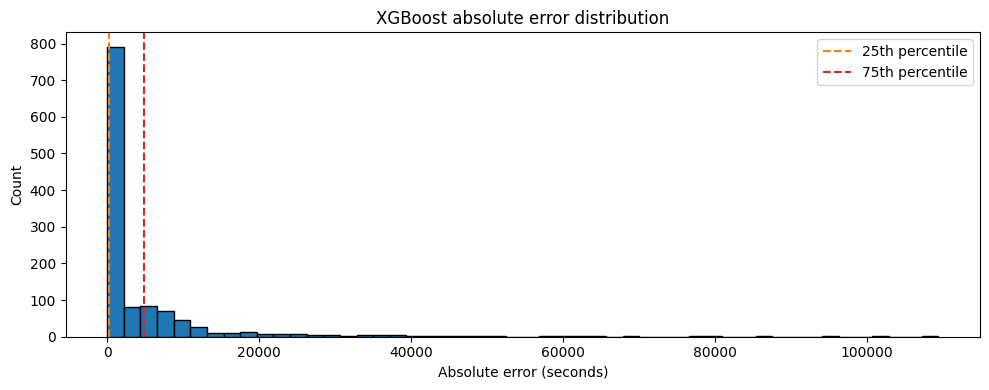

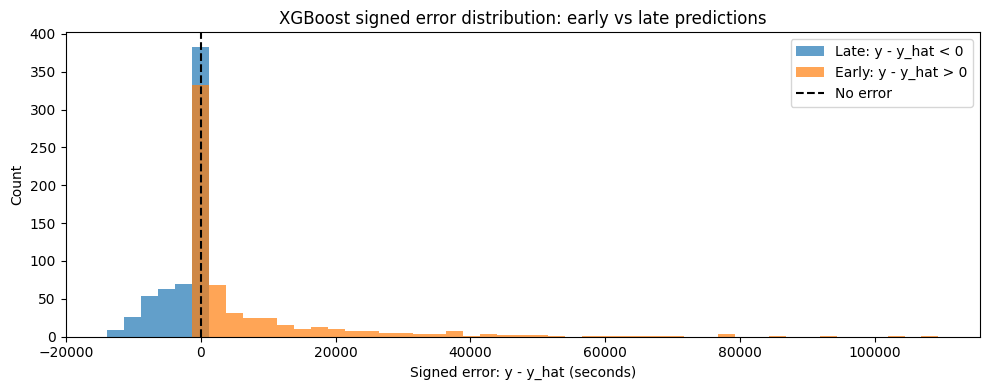

Middle-50% MAE: 1251.442946 seconds
Middle-50% MAE: 20.857382 minutes


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

absolute_errors = xgb_test_predictions["absolute_error"]
lower_quartile = absolute_errors.quantile(0.25)
upper_quartile = absolute_errors.quantile(0.75)
middle_quartile_errors = absolute_errors[
    absolute_errors.between(lower_quartile, upper_quartile, inclusive="both")
]
middle_quartile_mae = middle_quartile_errors.mean()

plt.figure(figsize=(10, 4))
plt.hist(absolute_errors, bins=50, edgecolor="black")
plt.axvline(lower_quartile, color="tab:orange", linestyle="--", label="25th percentile")
plt.axvline(upper_quartile, color="tab:red", linestyle="--", label="75th percentile")
plt.xlabel("Absolute error (seconds)")
plt.ylabel("Count")
plt.title("XGBoost absolute error distribution")
plt.legend()
plt.tight_layout()
plt.show()

signed_errors = xgb_test_predictions["y_true"] - xgb_test_predictions["y_pred"]
early_errors = signed_errors[signed_errors > 0]
late_errors = signed_errors[signed_errors < 0]
signed_error_bins = np.linspace(signed_errors.min(), signed_errors.max(), 50)

plt.figure(figsize=(10, 4))
plt.hist(late_errors, bins=signed_error_bins, alpha=0.7, label="Late: y - y_hat < 0")
plt.hist(early_errors, bins=signed_error_bins, alpha=0.7, label="Early: y - y_hat > 0")
plt.axvline(0, color="black", linestyle="--", label="No error")
plt.xlabel("Signed error: y - y_hat (seconds)")
plt.ylabel("Count")
plt.title("XGBoost signed error distribution: early vs late predictions")
plt.legend()
plt.tight_layout()
plt.show()

print(f"Middle-50% MAE: {middle_quartile_mae:.6f} seconds")
print(f"Middle-50% MAE: {middle_quartile_mae / 60:.6f} minutes")